In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

import imageio
import numpy as np

import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')

/tmp/ipykernel_861/2032054883.py:12: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg')


## Get the VGG19 and Freeze All Layers


In [77]:
vggnet = torchvision.models.vgg16(pretrained=True)

for p in vggnet.parameters():
    p.requires_grad = False

# set the evaluation mode
vggnet.eval()

print() # for no output returns

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [78]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vggnet.to(device)

print()

**_These images are taken from [this link](https://www.tensorflow.org/tutorials/generative/style_transfer)._**


In [79]:
image4content = imageio.v2.imread('https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/dl-pytorch/style-transfer/style_transfer1.jpg')

image4target = np.random.randint(0, 255, size=image4content.shape).astype(np.uint8)

image4style = imageio.v2.imread('https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/dl-pytorch/style-transfer/style_transfer2.jpg')

print(image4content.shape,image4target.shape,image4style.shape)

(577, 700, 3) (577, 700, 3) (657, 1000, 3)


In [80]:
ts = T.Compose([
    T.ToTensor(),
    T.Resize((256, 256)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # these are the number that vgg was trained on, and it expects the input to be normalized with these values
])

# unsqueeze(0) is used to add a batch dimension, since pytorch models expect the input to have a batch dimension
image4content_t = ts(image4content).unsqueeze(0).to(device)
image4target_t = ts(image4target).unsqueeze(0).to(device)
image4style_t = ts(image4style).unsqueeze(0).to(device)

image4content_t.shape, image4target_t.shape, image4style_t.shape

(torch.Size([1, 3, 256, 256]),
 torch.Size([1, 3, 256, 256]),
 torch.Size([1, 3, 256, 256]))

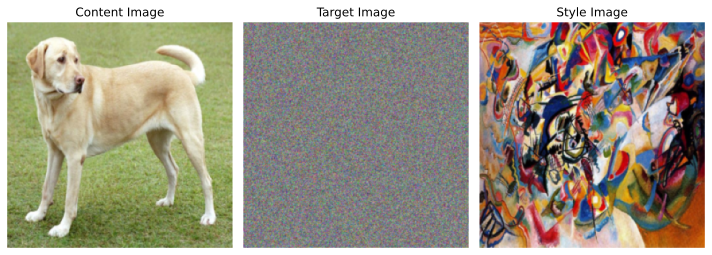

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def unnormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    # tensor: (1, C, H, W) -> returns (H, W, C) numpy array, clipped to [0, 1]
    img = tensor.squeeze(0).detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, img, title in zip(
    axes,
    [unnormalize(image4content_t), unnormalize(image4target_t), unnormalize(image4style_t)],
    ["Content Image", "Target Image", "Style Image"]
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Function to extract feature map activations


In [82]:
def getFeatureMapActs(image, net):
    featuresmaps = []
    featurenames = []

    convlayeridx = 0

    for layernum in range(len(net.features)):
        # pass the image through the network layer by layer
        image = net.features[layernum](image)

        # only store the iamge if it is a conv layer
        if isinstance(net.features[layernum], nn.Conv2d):
            featurenames.append(f'conv{layernum}')
            featuresmaps.append(image)
            convlayeridx += 1

    return featuresmaps, featurenames

## Gram Matrix

The **Gram matrix** captures which features in a layer tend to activate _together_, regardless of _where_ in the image they activate. This makes it a good representation of an image's **style** (textures, colors, patterns) while throwing away spatial/content information - exactly what's needed for neural style transfer.

### What the code does

1. **Flatten spatial dimensions**: A feature map of shape `(1, C, H, W)` (batch, channels, height, width) is reshaped into `(C, H*W)` - each row is one channel, "unrolled" into a single vector of length `H*W`.
2. **Compute the Gram matrix**: Multiply this matrix by its own transpose:

$$
G = M M^T
$$

where $M \in \mathbb{R}^{C \times (H \cdot W)}$. The result $G$ is a $C \times C$ matrix.

### The formula, element by element

Each entry $G_{ij}$ is the **dot product between channel $i$'s activations and channel $j$'s activations**, summed over every spatial position:

$$
G_{ij} = \sum_{k=1}^{H \cdot W} M_{ik} \, M_{jk}
$$

- **Diagonal entries** ($i = j$) measure how "active" or energetic a single channel/feature is overall.
- **Off-diagonal entries** ($i \neq j$) measure how much two different channels/features co-occur - i.e., how correlated they are across the image.

Because the sum runs over all spatial locations, any information about _where_ a feature occurred is discarded - only the overall statistical relationship between feature channels survives. That's why the Gram matrix represents _style_ rather than _content_.

### One thing to watch

This code assumes a **batch size of 1** (it discards the batch dim in `M.shape` and reshapes straight to `(chans, height*width)`). If you ever pass in a batch of more than one image, this will silently produce wrong results - you'd need to loop over the batch or reshape more carefully (e.g., `M.reshape(batch, chans, height*width)` and do a batched matrix multiply).


In [83]:
def gram_matrix(M):
    _, chans, height, width = M.shape
    M = M.reshape(chans, height*width) # reshape to 2d, x axis is the channels, y axis is the height*width
    G = torch.mm(M, M.t())
    return G / (chans * height * width)   # normalize by number of elements

## Getting Feature Maps of content image


In [84]:
featuremaps_content, featurenames_content = getFeatureMapActs(image4content_t, vggnet)

for i in range(len(featuremaps_content)):
    print(f'{i + 1}. Feature map {featurenames_content[i]} has shape {featuremaps_content[i].shape}')

1. Feature map conv0 has shape torch.Size([1, 64, 256, 256])
2. Feature map conv2 has shape torch.Size([1, 64, 256, 256])
3. Feature map conv5 has shape torch.Size([1, 128, 128, 128])
4. Feature map conv7 has shape torch.Size([1, 128, 128, 128])
5. Feature map conv10 has shape torch.Size([1, 256, 64, 64])
6. Feature map conv12 has shape torch.Size([1, 256, 64, 64])
7. Feature map conv14 has shape torch.Size([1, 256, 64, 64])
8. Feature map conv17 has shape torch.Size([1, 512, 32, 32])
9. Feature map conv19 has shape torch.Size([1, 512, 32, 32])
10. Feature map conv21 has shape torch.Size([1, 512, 32, 32])
11. Feature map conv24 has shape torch.Size([1, 512, 16, 16])
12. Feature map conv26 has shape torch.Size([1, 512, 16, 16])
13. Feature map conv28 has shape torch.Size([1, 512, 16, 16])


**_Plotting first 4 conv layer outputs and their gram matrix_**


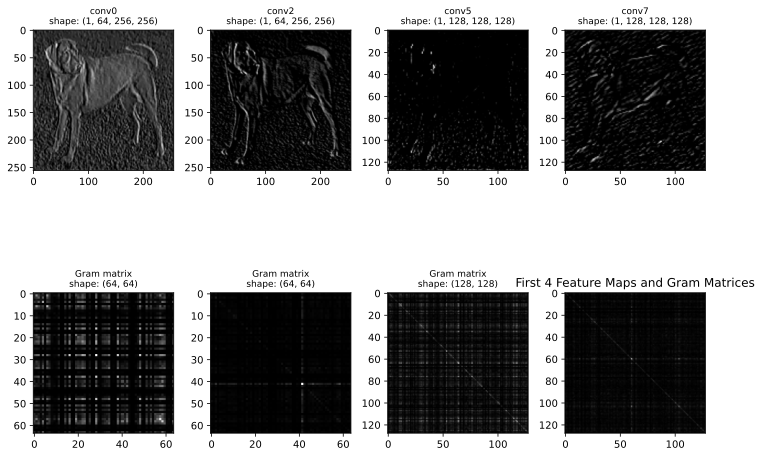

In [91]:
import matplotlib.pyplot as plt

n_show = 4

fig, axes = plt.subplots(2, n_show, figsize=(10, 8))

for col in range(n_show):
    fmap = featuremaps_content[col]
    gram = gram_matrix(fmap)

    axes[0, col].imshow(fmap[0, 0, :, :].detach().cpu().numpy(), cmap='gray')
    axes[0, col].set_title(f'{featurenames_content[col]}\nshape: {tuple(fmap.shape)}', fontsize=9)

    axes[1, col].imshow(gram.detach().cpu().numpy(), cmap='gray')
    axes[1, col].set_title(f'Gram matrix\nshape: {tuple(gram.shape)}', fontsize=9)

plt.title('First 4 Feature Maps and Gram Matrices', fontsize=12)
plt.tight_layout()
plt.show()

## Getting feature maps of style image


In [86]:
featuremaps_style, featurenames_style = getFeatureMapActs(image4style_t, vggnet)

for i in range(len(featuremaps_style)):
    print(f'{i + 1}. Feature map {featurenames_style[i]} has shape {featuremaps_style[i].shape}')

1. Feature map conv0 has shape torch.Size([1, 64, 256, 256])
2. Feature map conv2 has shape torch.Size([1, 64, 256, 256])
3. Feature map conv5 has shape torch.Size([1, 128, 128, 128])
4. Feature map conv7 has shape torch.Size([1, 128, 128, 128])
5. Feature map conv10 has shape torch.Size([1, 256, 64, 64])
6. Feature map conv12 has shape torch.Size([1, 256, 64, 64])
7. Feature map conv14 has shape torch.Size([1, 256, 64, 64])
8. Feature map conv17 has shape torch.Size([1, 512, 32, 32])
9. Feature map conv19 has shape torch.Size([1, 512, 32, 32])
10. Feature map conv21 has shape torch.Size([1, 512, 32, 32])
11. Feature map conv24 has shape torch.Size([1, 512, 16, 16])
12. Feature map conv26 has shape torch.Size([1, 512, 16, 16])
13. Feature map conv28 has shape torch.Size([1, 512, 16, 16])


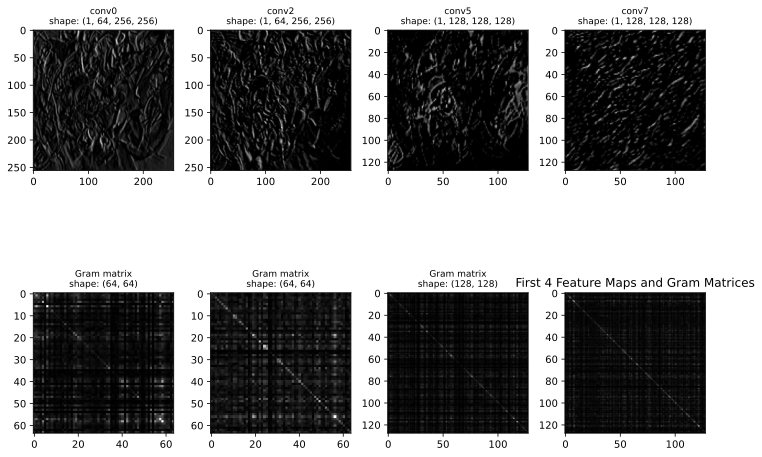

In [92]:
import matplotlib.pyplot as plt

n_show = 4

fig, axes = plt.subplots(2, n_show, figsize=(10, 8))

for col in range(n_show):
    fmap = featuremaps_style[col]
    gram = gram_matrix(fmap)

    axes[0, col].imshow(fmap[0, 0, :, :].detach().cpu().numpy(), cmap='gray')
    axes[0, col].set_title(f'{featurenames_style[col]}\nshape: {tuple(fmap.shape)}', fontsize=9)

    axes[1, col].imshow(gram.detach().cpu().numpy(), cmap='gray')
    axes[1, col].set_title(f'Gram matrix\nshape: {tuple(gram.shape)}', fontsize=9)

plt.title('First 4 Feature Maps and Gram Matrices', fontsize=12)
plt.tight_layout()
plt.show()

# NOW THE TRANSFER


In [88]:
# set the content and style layers to use for the loss calculation

layers4content = ['conv0', 'conv7']
layers4style = ['conv0', 'conv2', 'conv5', 'conv7', 'conv10']

# Per-layer weights for the style loss, one weight per entry in layers4style, in the same order.
# Earlier layers (e.g. conv0) capture fine-grained style: colors, edges, small textures.
# while deeper layers (e.g. conv10) capture more abstract, larger-scale patterns.
# Weighting earlier layers more heavily (1, .5) and later layers less (.5, .2, .1) biases
# the style loss toward fine textures/colors rather than high-level structure, which tends
# to produce more visually convincing "style" (brushstrokes, texture) without overpowering
# the content. These are hyperparameters.
# toward finer detail (increase early weights) or broader pattern (increase later weights).

weights4style = [1, .5, .5, .2, .1]

# What happens in 1 epoch

This is a **neural style transfer** loop - each epoch nudges the `target` image to look more like the content image while adopting the style image's texture/patterns.

1. **Extract features from the current target image**
   `targetfeaturemaps, targetfeaturenames = getFeatureMapActs(target, vggnet)` - runs `target` through the pretrained VGG network and grabs the activation maps at each layer.

2. **Loop over every VGG layer** and accumulate two losses:
   - **Content loss**: for layers designated as content layers (`layers4content`), compute the MSE between the target's feature map and the precomputed content image's feature map (`featuremaps_content`). This measures how far the target has drifted structurally/semantically from the content image.
   - **Style loss**: for layers designated as style layers (`layers4style`), compute the Gram matrix (which captures texture/style correlations) of both the target's and the style image's feature maps, then take the MSE between them - weighted by `weights4style` for that layer. This measures how far the target's texture is from the style image's texture.

3. **Combine the losses**
   `combineloss = contentloss + style_scalar * styleloss` - style loss is scaled up by `1e6` since it's naturally much smaller in magnitude than content loss, so without scaling it'd barely influence the optimization.

4. **Backpropagate and update**
   - `optimizer.zero_grad()` clears old gradients
   - `combineloss.backward()` computes gradients of the combined loss **with respect to the pixels of `target`** (not the network weights - VGG is frozen; only the image is being optimized)
   - `optimizer.step()` updates `target`'s pixel values via RMSprop to slightly reduce the combined loss

So in short: **one epoch = one gradient step that pushes the target image's pixels to simultaneously match the content image's structure and the style image's texture, a little bit at a time.** Over 1500 epochs, this gradually morphs `target` into a stylized image.


In [89]:
target = image4content_t.clone().requires_grad_(True).to(device)

style_scalar = 1e6  # style loss is typically much smaller than content loss, so we scale it up to make it comparable

numepochs = 1500

optimizer = torch.optim.RMSprop([target], lr=0.005)  # original paper recommends L-BFGS, but RMSprop is faster and works well enough for this demo

for epoch in range(numepochs):
    targetfeaturemaps, targetfeaturenames = getFeatureMapActs(target, vggnet)

    styleloss = 0
    contentloss = 0

    for layeri in range(len(targetfeaturenames)):

        # compute the content loss
        if targetfeaturenames[layeri] in layers4content:
            # compute the mean squared error between the target feature map and the content feature map
            contentloss += torch.mean((targetfeaturemaps[layeri] - featuremaps_content[layeri]) ** 2)

        # compute the style loss
        if targetfeaturenames[layeri] in layers4style:
            styleloss += weights4style[layers4style.index(targetfeaturenames[layeri])] * torch.mean(
                (gram_matrix(targetfeaturemaps[layeri]) - gram_matrix(featuremaps_style[layeri])) ** 2
            )

    combineloss = contentloss + style_scalar * styleloss

    # ready for backpropagation
    optimizer.zero_grad()
    combineloss.backward()
    optimizer.step()

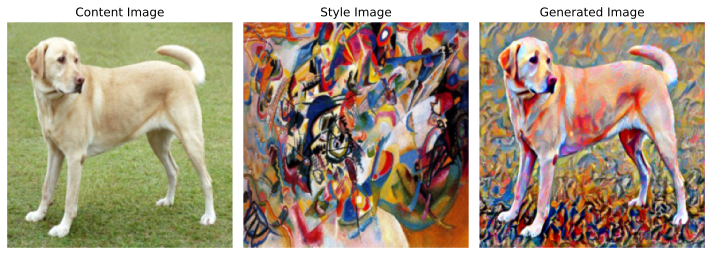

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def unnormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    # tensor: (1, C, H, W) -> returns (H, W, C) numpy array, clipped to [0, 1]
    img = tensor.squeeze(0).detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, img, title in zip(
    axes,
    [unnormalize(image4content_t), unnormalize(image4style_t), unnormalize(target)],
    ["Content Image", "Style Image", "Generated Image"]
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Same thing but with AlexNet.


In [93]:
alexnet = torchvision.models.alexnet(pretrained=True)

for p in alexnet.parameters():
    p.requires_grad = False

alexnet.eval()
alexnet.to(device)

print()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:05<00:00, 43.9MB/s] 


In [94]:
image4content_alex = imageio.v2.imread('https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/dl-pytorch/style-transfer/style_transfer3.jpg')

image4target_alex = np.random.randint(0, 255, size=image4content_alex.shape).astype(np.uint8)

image4style_alex = imageio.v2.imread('https://raw.githubusercontent.com/umerkang66/ai-ml-dl/refs/heads/master/dl-pytorch/style-transfer/style_transfer4.jpg')

print(image4content_alex.shape, image4target_alex.shape, image4style_alex.shape)


(640, 612, 3) (640, 612, 3) (4126, 3240, 3)


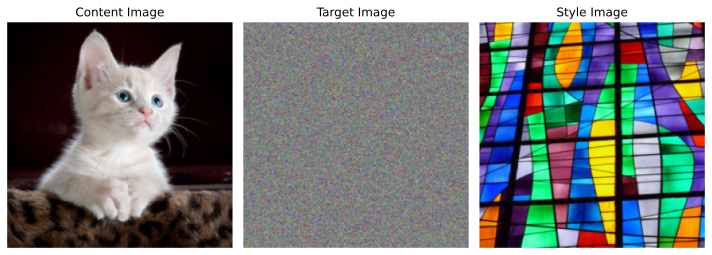

In [95]:
image4content_alex_t = ts(image4content_alex).unsqueeze(0).to(device)
image4target_alex_t = ts(image4target_alex).unsqueeze(0).to(device)
image4style_alex_t = ts(image4style_alex).unsqueeze(0).to(device)

image4content_alex_t.shape, image4target_alex_t.shape, image4style_alex_t.shape

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, img, title in zip(
    axes,
    [unnormalize(image4content_alex_t), unnormalize(image4target_alex_t), unnormalize(image4style_alex_t)],
    ["Content Image", "Target Image", "Style Image"]
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [97]:
featuremaps_content_alex, featurenames_content_alex = getFeatureMapActs(image4content_alex_t, alexnet)

for i in range(len(featuremaps_content_alex)):
    print(f'{i + 1}. Feature map {featurenames_content_alex[i]} has shape {featuremaps_content_alex[i].shape}')

featuremaps_style_alex, featurenames_style_alex = getFeatureMapActs(image4style_alex_t, alexnet)

for i in range(len(featuremaps_style_alex)):
    print(f'{i + 1}. Feature map {featurenames_style_alex[i]} has shape {featuremaps_style_alex[i].shape}')

1. Feature map conv0 has shape torch.Size([1, 64, 63, 63])
2. Feature map conv3 has shape torch.Size([1, 192, 31, 31])
3. Feature map conv6 has shape torch.Size([1, 384, 15, 15])
4. Feature map conv8 has shape torch.Size([1, 256, 15, 15])
5. Feature map conv10 has shape torch.Size([1, 256, 15, 15])
1. Feature map conv0 has shape torch.Size([1, 64, 63, 63])
2. Feature map conv3 has shape torch.Size([1, 192, 31, 31])
3. Feature map conv6 has shape torch.Size([1, 384, 15, 15])
4. Feature map conv8 has shape torch.Size([1, 256, 15, 15])
5. Feature map conv10 has shape torch.Size([1, 256, 15, 15])


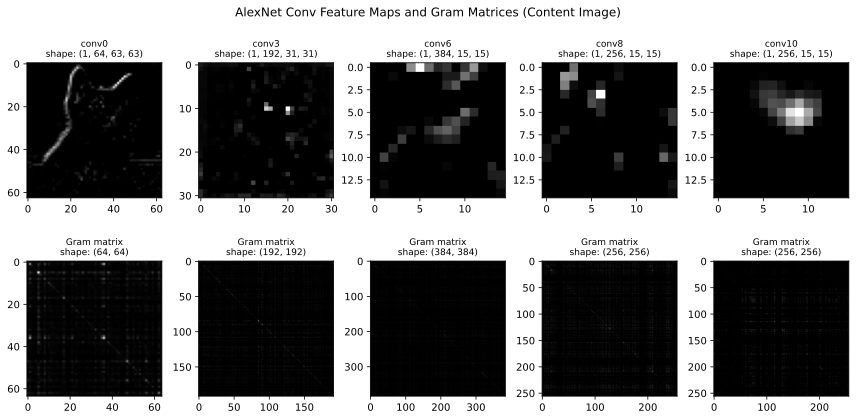

In [98]:
n_show = len(featuremaps_content_alex)

fig, axes = plt.subplots(2, n_show, figsize=(12, 6))

for col in range(n_show):
    fmap = featuremaps_content_alex[col]
    gram = gram_matrix(fmap)

    axes[0, col].imshow(fmap[0, 0, :, :].detach().cpu().numpy(), cmap='gray')
    axes[0, col].set_title(f'{featurenames_content_alex[col]}\nshape: {tuple(fmap.shape)}', fontsize=9)

    axes[1, col].imshow(gram.detach().cpu().numpy(), cmap='gray')
    axes[1, col].set_title(f'Gram matrix\nshape: {tuple(gram.shape)}', fontsize=9)

plt.suptitle('AlexNet Conv Feature Maps and Gram Matrices (Content Image)', fontsize=12)
plt.tight_layout()
plt.show()

In [99]:
layers4content_alex = ['conv6']
layers4style_alex = ['conv0', 'conv3', 'conv6', 'conv8', 'conv10']

weights4style_alex = [1, .5, .3, .2, .1]

target_alex = image4content_alex_t.clone().requires_grad_(True).to(device)

style_scalar_alex = 1e6

numepochs = 1500

optimizer = torch.optim.RMSprop([target_alex], lr=0.005)

for epoch in range(numepochs):
    targetfeaturemaps, targetfeaturenames = getFeatureMapActs(target_alex, alexnet)

    styleloss = 0
    contentloss = 0

    for layeri in range(len(targetfeaturenames)):

        if targetfeaturenames[layeri] in layers4content_alex:
            contentloss += torch.mean((targetfeaturemaps[layeri] - featuremaps_content_alex[layeri]) ** 2)

        if targetfeaturenames[layeri] in layers4style_alex:
            styleloss += weights4style_alex[layers4style_alex.index(targetfeaturenames[layeri])] * torch.mean(
                (gram_matrix(targetfeaturemaps[layeri]) - gram_matrix(featuremaps_style_alex[layeri])) ** 2
            )

    combineloss = contentloss + style_scalar_alex * styleloss

    optimizer.zero_grad()
    combineloss.backward()
    optimizer.step()


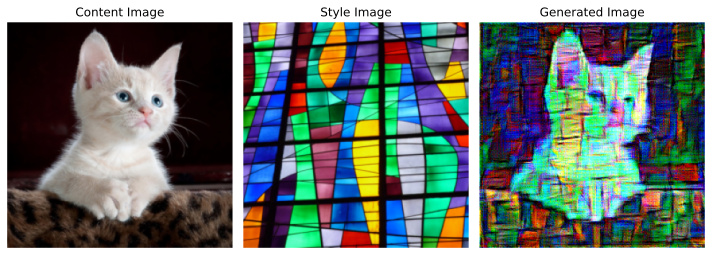

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for ax, img, title in zip(
    axes,
    [unnormalize(image4content_alex_t), unnormalize(image4style_alex_t), unnormalize(target_alex)],
    ["Content Image", "Style Image", "Generated Image"]
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()